# 1. Install / Import

In [1]:
!pip install ultralytics -q

In [2]:
import os
import random
import yaml
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 2. Define Paths

In [3]:
DATASET_PATH = "/kaggle/input/datasets/suhaibalajami/shaheen-desret-dataset/real_data"
YAML_PATH = f"{DATASET_PATH}/data.yaml"

PRETRAINED_MODEL = "/kaggle/input/models/suhaibalajami/sard-yolov8-best-model/other/default/1/best_sard_yolov8n.pt"

TRAIN_IMAGES = f"{DATASET_PATH}/images/train"
VAL_IMAGES   = f"{DATASET_PATH}/images/val"
TEST_IMAGES  = f"{DATASET_PATH}/images/test"

TRAIN_LABELS = f"{DATASET_PATH}/labels/train"
VAL_LABELS   = f"{DATASET_PATH}/labels/val"
TEST_LABELS  = f"{DATASET_PATH}/labels/test"

# 3. Check Dataset Structure

In [24]:
for split in ["train", "val", "test"]:
    img_dir = f"{DATASET_PATH}/images/{split}"
    lbl_dir = f"{DATASET_PATH}/labels/{split}"

    images = os.listdir(img_dir)
    labels = os.listdir(lbl_dir)

    print(f"{split.upper()}")
    print("Images:", len(images))
    print("Labels:", len(labels))
    print("-" * 30)

TRAIN
Images: 4939
Labels: 4939
------------------------------
VAL
Images: 706
Labels: 706
------------------------------
TEST
Images: 1411
Labels: 1411
------------------------------


# 4. Check Missing Labels

In [25]:
for split in ["train", "val", "test"]:
    img_dir = f"{DATASET_PATH}/images/{split}"
    lbl_dir = f"{DATASET_PATH}/labels/{split}"

    images = {
        os.path.splitext(f)[0]
        for f in os.listdir(img_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    }

    labels = {
        os.path.splitext(f)[0]
        for f in os.listdir(lbl_dir)
        if f.lower().endswith(".txt")
    }

    print(split)
    print("Missing labels:", len(images - labels))
    print("Extra labels:", len(labels - images))
    print()

train
Missing labels: 0
Extra labels: 0

val
Missing labels: 0
Extra labels: 0

test
Missing labels: 0
Extra labels: 0



# 7. Count Empty Labels vs Human Labels 

In [26]:
for split in ["train", "val", "test"]:
    lbl_dir = f"{DATASET_PATH}/labels/{split}"

    empty = 0
    non_empty = 0

    for file in os.listdir(lbl_dir):
        if file.endswith(".txt"):
            path = os.path.join(lbl_dir, file)

            if os.path.getsize(path) == 0:
                empty += 1
            else:
                non_empty += 1

    print(split.upper())
    print("Images with human:", non_empty)
    print("Images without human:", empty)
    print("-" * 30)

TRAIN
Images with human: 2270
Images without human: 2669
------------------------------
VAL
Images with human: 324
Images without human: 382
------------------------------
TEST
Images with human: 648
Images without human: 763
------------------------------


# 8. Visualize Sample Images with Labels

In [27]:
def show_sample(split="train"):
    img_dir = f"{DATASET_PATH}/images/{split}"
    lbl_dir = f"{DATASET_PATH}/labels/{split}"

    image_files = [
        f for f in os.listdir(img_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_name = random.choice(image_files)

    img_path = os.path.join(img_dir, image_name)
    lbl_path = os.path.join(
        lbl_dir,
        os.path.splitext(image_name)[0] + ".txt"
    )

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            if line.strip() == "":
                continue

            cls, x_center, y_center, box_w, box_h = map(float, line.split())

            x_center *= w
            y_center *= h
            box_w *= w
            box_h *= h

            x1 = int(x_center - box_w / 2)
            y1 = int(y_center - box_h / 2)
            x2 = int(x_center + box_w / 2)
            y2 = int(y_center + box_h / 2)

            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_name)
    plt.show()

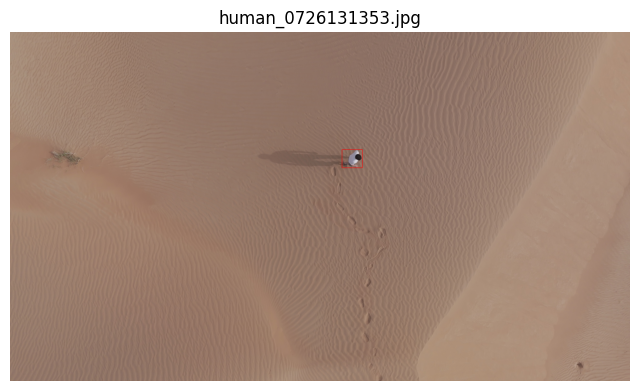

In [28]:
show_sample("train")

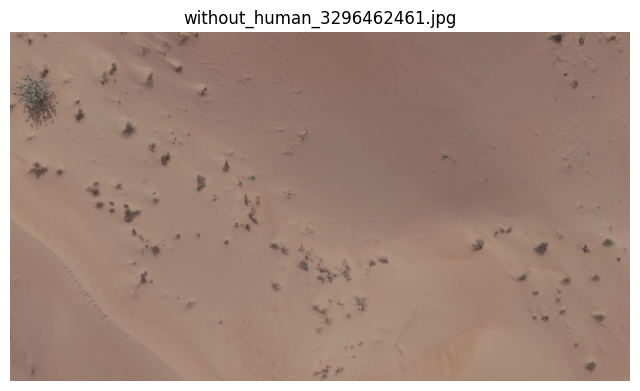

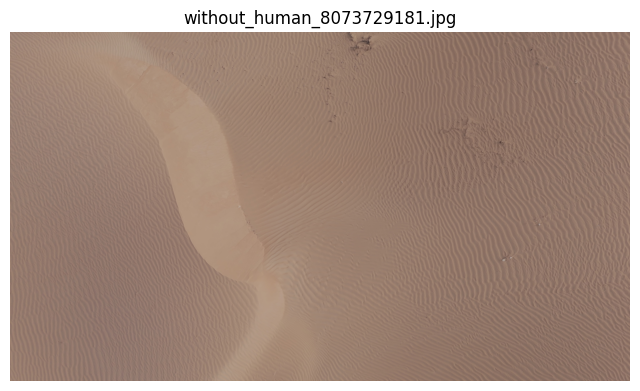

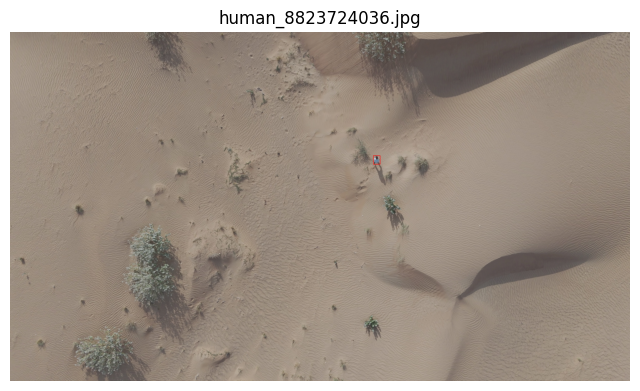

In [29]:
show_sample("train")
show_sample("val")
show_sample("test")

# 9. Load Pretrained YOLOv8n

In [30]:
model = YOLO(PRETRAINED_MODEL)
# model = YOLO("yolov8n.pt")

# 10. Fine-Tune the Model

In [33]:
results = model.train(
    data="/kaggle/input/datasets/suhaibalajami/shaheen-desret-dataset/real_data/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,

    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,

    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.4,
    degrees=5,
    translate=0.10,
    scale=0.50,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.10,

    project="/kaggle/working/runs",
    name="shaheen_yolov8n_finetune"
)

Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/suhaibalajami/shaheen-desret-dataset/real_data/data.yaml, degrees=5, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/kaggle/input/models/suhaibalajami/sard-yolov8-best-model/other/default/1/best_sard_yolov8n.pt, momentum=0.937, mo

# 11. Validate Best Model

In [4]:
best_model_path = "/kaggle/working/runs/shaheen_yolov8n_finetune-2/weights/best.pt"

best_model = YOLO(best_model_path)

metrics = best_model.val(
    data="/kaggle/input/datasets/suhaibalajami/shaheen-desret-dataset/real_data/data.yaml",
    split="val"
)

Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 61.0±34.9 MB/s, size: 1391.9 KB)
val: Scanning /kaggle/input/datasets/suhaibalajami/shaheen-desret-dataset/real_data/labels/val... 706 images, 382 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 706/706 198.6it/s 3.6s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/suhaibalajami/shaheen-desret-dataset/real_data/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 45/45 1.6it/s 28.0s0.3s
                   all        706        343      0.988       0.99      0.994       0.65
Speed: 0.7ms preprocess, 3.0ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-8


# 12. Test Set Evaluation

In [5]:
test_metrics = best_model.val(
    data="/kaggle/input/datasets/suhaibalajami/shaheen-desret-dataset/real_data/data.yaml",
    split="test"
)

Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 115.2±44.4 MB/s, size: 1404.7 KB)
val: Scanning /kaggle/input/datasets/suhaibalajami/shaheen-desret-dataset/real_data/labels/test... 1411 images, 763 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1411/1411 172.2it/s 8.2s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/suhaibalajami/shaheen-desret-dataset/real_data/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 89/89 2.2it/s 40.5s0.9ss
                   all       1411        688      0.975      0.985      0.979      0.626
Speed: 0.6ms preprocess, 2.7ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-9


# 13. Run Predictions on Test Images

In [ ]:
pred_results = best_model.predict(
    source=TEST_IMAGES,
    conf=0.25,
    save=True,
    project="/kaggle/working/predictions",
    name="test_predictions"
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1411 /kaggle/input/datasets/suhaibalajami/shaheen-desret-dataset/real_data/images/test/human_0004282761.jpg: 384x640 1 human, 44.0ms
image 2/1411 /kaggle/input/datasets/suhaibalajami/shaheen-desret-dataset/real_data/images/test/human_0017117487.jpg: 384x640 1 human, 6.2ms
image 3/1411 /kaggle/input/datasets/suhaibalajami/shaheen-desret-dataset/real_data/images/test/human_0021202486.jpg: 384x640 1 human, 6.5ms
image 4/1411 /kaggle/input/datasets/s

# 14. Show Prediction Samples

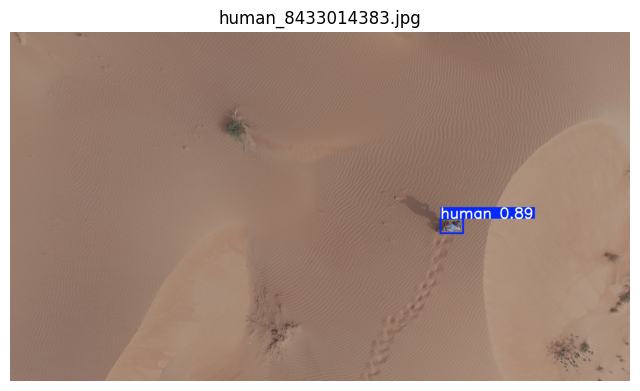

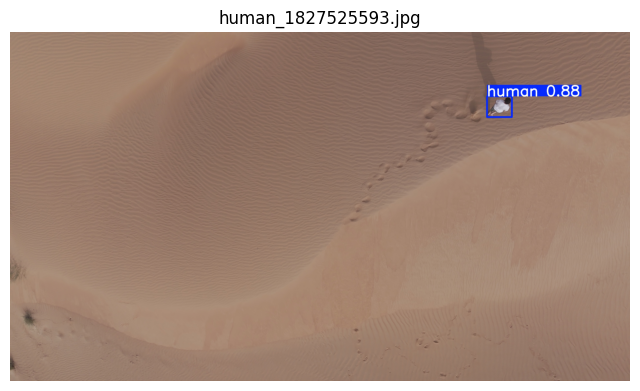

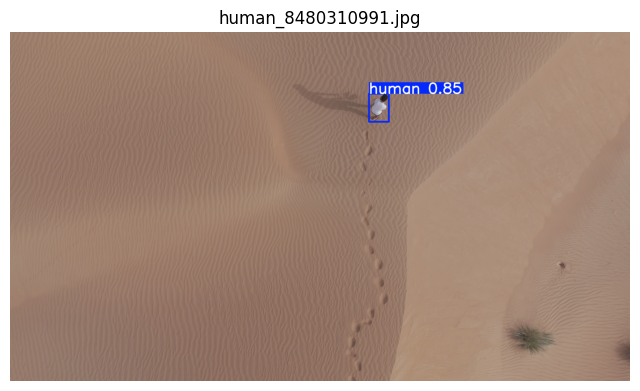

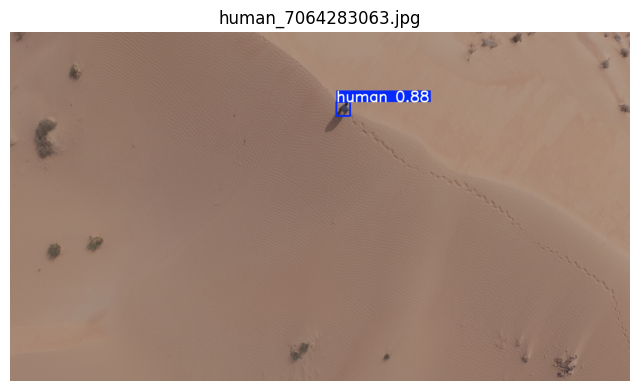

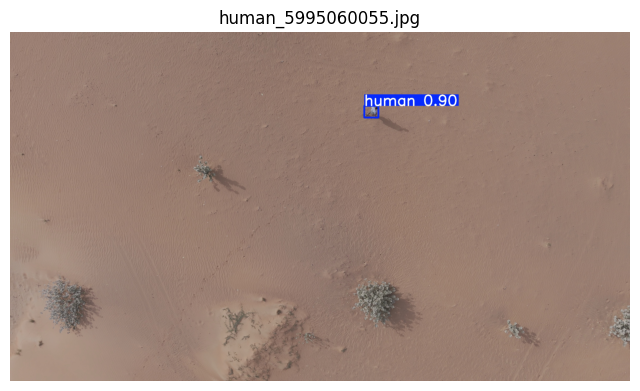

In [6]:
PRED_DIR = "/kaggle/working/predictions/test_predictions"

pred_images = [
    f for f in os.listdir(PRED_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for img_name in random.sample(pred_images, min(5, len(pred_images))):
    img_path = os.path.join(PRED_DIR, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)
    plt.show()

# 15. Show Training Curves

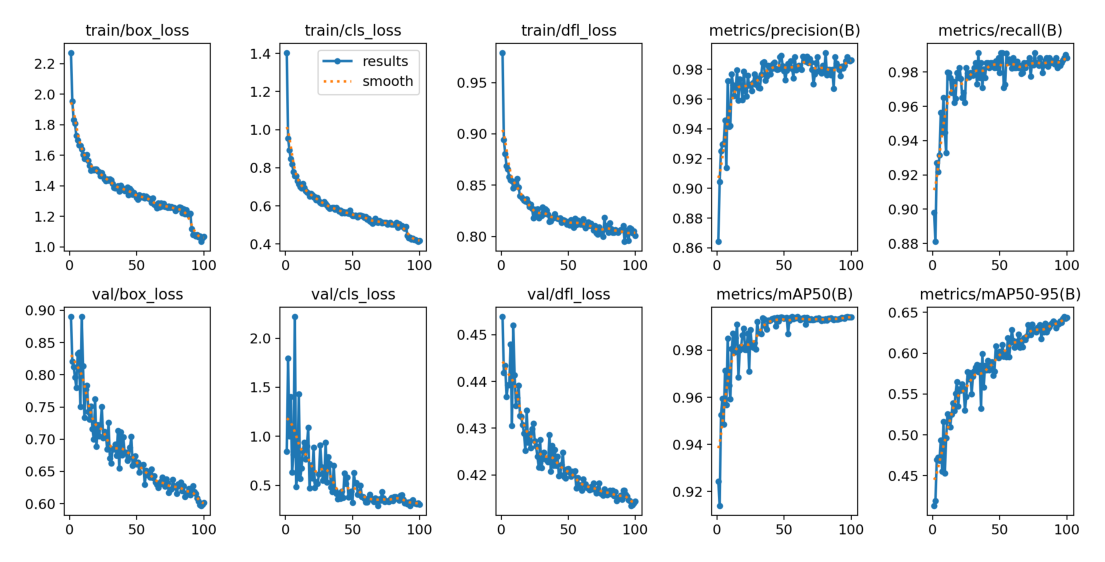

In [7]:
results_img = "/kaggle/working/runs/shaheen_yolov8n_finetune-2/results.png"

img = cv2.imread(results_img)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 10))
plt.imshow(img)
plt.axis("off")
plt.show()

# 16. Export Model

In [8]:
best_model.export(format="onnx")

Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/shaheen_yolov8n_finetune-2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 185ms
Prepared 2 packages in 4.45s
Installed 2 packages in 11ms
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 5.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 6.6s, saved as '/kaggle/working/runs/shaheen_yolov8n_finetune-2/weig

'/kaggle/working/runs/shaheen_yolov8n_finetune-2/weights/best.onnx'